<a href="https://colab.research.google.com/github/ranggatimotius/KNN_ParkingSpace_Prediction/blob/main/KNN_PublicParking_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Library**

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# **LOAD DATASET**

In [ ]:
from google.colab import files
uploaded = files.upload()

import io
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("File:", filename)
print("Shape:", df.shape)
df.head()

Saving IIoT_Smart_Parking_Management.csv to IIoT_Smart_Parking_Management.csv
File: IIoT_Smart_Parking_Management.csv
Shape: (1000, 28)


,Timestamp,Parking_Spot_ID,Sensor_Reading_Proximity,Sensor_Reading_Pressure,Vehicle_Type_Weight,Vehicle_Type_Height,User_Type,Weather_Temperature,Weather_Precipitation,Nearby_Traffic_Level,...,Occupancy_Status,Vehicle_Type,Parking_Violation,Sensor_Reading_Ultrasonic,Parking_Duration,Environmental_Noise_Level,Dynamic_Pricing_Factor,Spot_Size,Proximity_To_Exit,User_Parking_History
0,2021-01-01 00:00:00.000000000,20,1.023651,1.541461,1831.770127,4.392528,Visitor,18.092553,1,Low,...,Occupied,Car,0,102.951052,4,55.620740,0.8,Standard,6.610474,6.660310
1,2021-01-02 06:39:16.756756756,49,3.903349,1.621719,1330.815754,4.595638,Registered,13.397533,0,Low,...,Occupied,Car,0,87.559131,3,56.682386,1.2,Compact,8.678719,6.766187
2,2021-01-03 13:18:33.513513513,38,10.315709,6.292374,1255.134827,4.313721,Registered,21.687410,0,High,...,Vacant,Car,1,100.061854,5,59.239322,0.8,Standard,13.795262,-0.910052
3,2021-01-04 19:57:50.270270270,31,6.588039,1.659870,1523.442919,3.567329,Visitor,18.683461,0,Medium,...,Vacant,Motorcycle,1,110.594598,2,44.545155,0.8,Standard,1.678721,10.415888
4,2021-01-06 02:37:07.027027027,8,8.213969,3.278467,1758.490837,5.145836,Visitor,19.214876,0,High,...,Occupied,Car,0,84.786963,2,48.012604,0.8,Standard,20.012252,4.355544


# **DATA UNDERSTANDING**

In [ ]:
display(df.info())

print("\nDistribusi Occupancy_Status:")
display(df['Occupancy_Status'].value_counts())
display(df['Occupancy_Status'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Timestamp                  1000 non-null   object 
 1   Parking_Spot_ID            1000 non-null   int64  
 2   Sensor_Reading_Proximity   1000 non-null   float64
 3   Sensor_Reading_Pressure    1000 non-null   float64
 4   Vehicle_Type_Weight        1000 non-null   float64
 5   Vehicle_Type_Height        1000 non-null   float64
 6   User_Type                  1000 non-null   object 
 7   Weather_Temperature        1000 non-null   float64
 8   Weather_Precipitation      1000 non-null   int64  
 9   Nearby_Traffic_Level       1000 non-null   object 
 10  Entry_Time                 1000 non-null   int64  
 11  Exit_Time                  1000 non-null   int64  
 12  Electric_Vehicle           1000 non-null   int64  
 13  Reserved_Status            1000 non-null   int64 

None


Distribusi Occupancy_Status:


,count
Occupancy_Status,
Occupied,550
Vacant,450


,proportion
Occupancy_Status,
Occupied,0.55
Vacant,0.45


# **TIMESTAMP TO TIME FITURE**

In [ ]:
df = df.copy()

df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
assert df['Timestamp'].isna().sum() == 0, "Ada Timestamp yang gagal diparse. Cek format datanya."

df['hour'] = df['Timestamp'].dt.hour
df['dayofweek'] = df['Timestamp'].dt.dayofweek

df = df.drop(columns=['Timestamp'])
df[['hour','dayofweek']].head()


,hour,dayofweek
0,0,4
1,6,5
2,13,6
3,19,0
4,2,2


# **ENCODING TARGET**


*   Vacant = 0
*   Occupied = 1



In [ ]:
target = 'Occupancy_Status'
y = df[target].map({'Vacant': 0, 'Occupied': 1})

if y.isna().any():
    print("Label target tidak sesuai mapping. Label unik:", df[target].unique())
    raise ValueError("Perbaiki mapping target di atas.")

y.value_counts()


,count
Occupancy_Status,
1,550
0,450


# **SELECTED FEATURE**
Kita hanya menggunakan beberapa fitur tertentu untuk mengurangi noise pada model dan menaikkan akurasi

In [ ]:
selected_features = [
    # lokasi
    'Parking_Spot_ID',
    'Proximity_To_Exit',
    'Parking_Lot_Section',

    # sensor (paling penting)
    'Sensor_Reading_Proximity',
    'Sensor_Reading_Ultrasonic',
    'Sensor_Reading_Pressure',

    # status spot
    'Reserved_Status',
    'Spot_Size',

    # waktu
    'hour',
    'dayofweek',
]

# Pastikan fitur ada di dataset
missing = [c for c in selected_features if c not in df.columns]
if missing:
    print("Fitur yang hilang:", missing)
    print("Kolom yang tersedia:", df.columns.tolist())
    raise KeyError("Ada fitur yang belum ada di dataset. Sesuaikan selected_features.")

X = df[selected_features].copy()
print("Jumlah fitur dipakai:", X.shape[1])
X.head()


Jumlah fitur dipakai: 10


,Parking_Spot_ID,Proximity_To_Exit,Parking_Lot_Section,Sensor_Reading_Proximity,Sensor_Reading_Ultrasonic,Sensor_Reading_Pressure,Reserved_Status,Spot_Size,hour,dayofweek
0,20,6.610474,Zone A,1.023651,102.951052,1.541461,1,Standard,0,4
1,49,8.678719,Zone A,3.903349,87.559131,1.621719,0,Compact,6,5
2,38,13.795262,Zone B,10.315709,100.061854,6.292374,0,Standard,13,6
3,31,1.678721,Zone B,6.588039,110.594598,1.659870,0,Standard,19,0
4,8,20.012252,Zone C,8.213969,84.786963,3.278467,1,Standard,2,2


# **DATA SPLIT**
Dilakukan supaya prorposi kelas seimbang

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Proporsi y_train:", y_train.value_counts(normalize=True).to_dict())
print("Proporsi y_test :", y_test.value_counts(normalize=True).to_dict())


Train: (800, 10) Test: (200, 10)
Proporsi y_train: {1: 0.55, 0: 0.45}
Proporsi y_test : {1: 0.55, 0: 0.45}


# **PIPELINE PREPROCESSING**
Beguna untuk menghubungkan seluruh persiapan data dan model ML menjadi alur yang benar dan konsisten.

Data in -> process -> predicting (PIPELINE)

In [ ]:
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)


Numeric: ['Parking_Spot_ID', 'Proximity_To_Exit', 'Sensor_Reading_Proximity', 'Sensor_Reading_Ultrasonic', 'Sensor_Reading_Pressure', 'Reserved_Status']
Categorical: ['Parking_Lot_Section', 'Spot_Size']


# **BASELINE KKN (WITH WEIGHT DISTANCE)**


In [ ]:
baseline_clf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=7, weights='distance', p=2))
])

baseline_clf.fit(X_train, y_train)
y_pred = baseline_clf.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Vacant(0)','Occupied(1)']))


Baseline Accuracy: 0.545
              precision    recall  f1-score   support

   Vacant(0)       0.49      0.43      0.46        90
 Occupied(1)       0.58      0.64      0.61       110

    accuracy                           0.55       200
   macro avg       0.54      0.53      0.53       200
weighted avg       0.54      0.55      0.54       200



# **CONFUSION MATRIX**

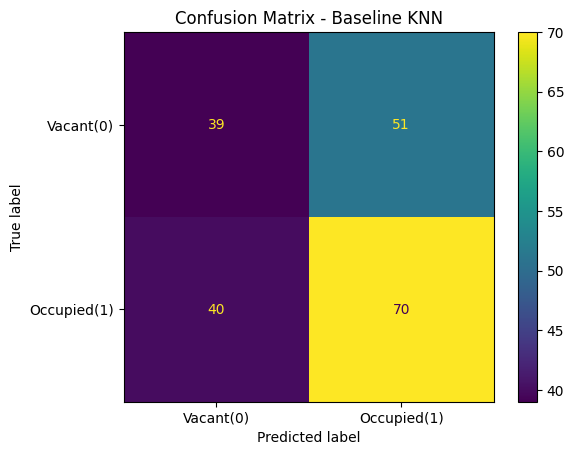

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Vacant(0)','Occupied(1)'])
disp.plot()
plt.title("Confusion Matrix - Baseline KNN")
plt.show()

# **TUNING**
Kita akan mencoba memperbaiki akurasi knn dengan cara GridSearchCV. Prosesnya adalah dengan mencari kombinasi terakurat dari nilai k dan p.

In [ ]:
param_grid = {
    'model__n_neighbors': [3,5,7,9,11,13,15,17,19],
    'model__p': [1,2],
    'model__weights': ['uniform','distance']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', KNeighborsClassifier())
    ]),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best CV Accuracy:", grid.best_score_)
print("Best Params:", grid.best_params_)


Best CV Accuracy: 0.5349999999999999
Best Params: {'model__n_neighbors': 17, 'model__p': 1, 'model__weights': 'distance'}


# **EVALUATE BEST MODEL TO USE**

In [ ]:
best_clf = grid.best_estimator_
y_pred_best = best_clf.predict(X_test)

print("Test Accuracy (Best):", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best, target_names=['Vacant(0)','Occupied(1)']))


Test Accuracy (Best): 0.51
              precision    recall  f1-score   support

   Vacant(0)       0.43      0.28      0.34        90
 Occupied(1)       0.54      0.70      0.61       110

    accuracy                           0.51       200
   macro avg       0.49      0.49      0.47       200
weighted avg       0.49      0.51      0.49       200



## **CONFUSION MATRIX (BEST MODEL)**

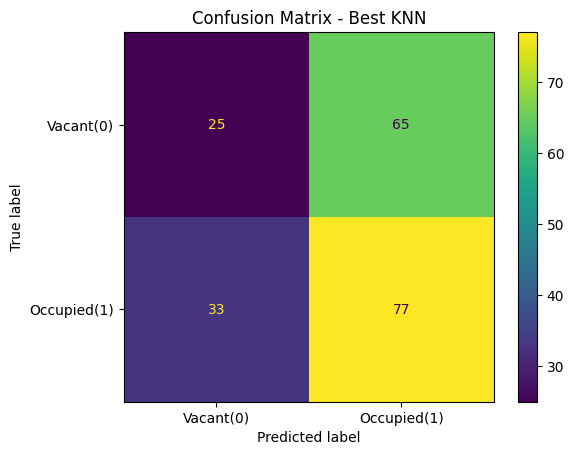

In [ ]:
cm_best = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['Vacant(0)','Occupied(1)'])
disp.plot()
plt.title("Confusion Matrix - Best KNN")
plt.show()


# **OCCUPANCY ANALYSIS**
Prediksi berdasarkan jam & hari

In [ ]:
df_analysis = df.copy()
df_analysis['y_true'] = y.values
df_analysis['y_pred'] = best_clf.predict(X)

# Rate occupied berdasarkan prediksi (1=occupied)
occ_by_hour = df_analysis.groupby('hour')['y_pred'].mean().sort_index()
occ_by_day = df_analysis.groupby('dayofweek')['y_pred'].mean().sort_index()

print("Predicted Occupancy Rate per Hour:")
display(occ_by_hour)

print("\nPredicted Occupancy Rate per Day (0=Mon ... 6=Sun):")
display(occ_by_day)

Predicted Occupancy Rate per Hour:


,y_pred
hour,
0,0.627907
1,0.476190
2,0.658537
3,0.642857
4,0.690476
5,0.609756
6,0.619048
7,0.658537
8,0.523810



Predicted Occupancy Rate per Day (0=Mon ... 6=Sun):


,y_pred
dayofweek,
0,0.559441
1,0.647887
2,0.587413
3,0.521127
4,0.548611
5,0.601399
6,0.608392


**BY HOUR**

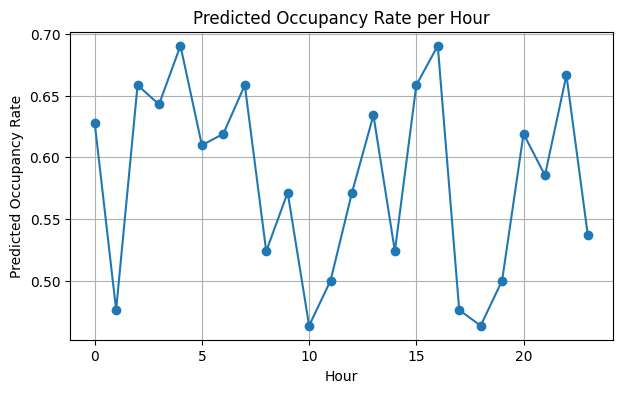

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(occ_by_hour.index, occ_by_hour.values, marker='o')
plt.xlabel("Hour")
plt.ylabel("Predicted Occupancy Rate")
plt.title("Predicted Occupancy Rate per Hour")
plt.grid(True)
plt.show()


BY DAY

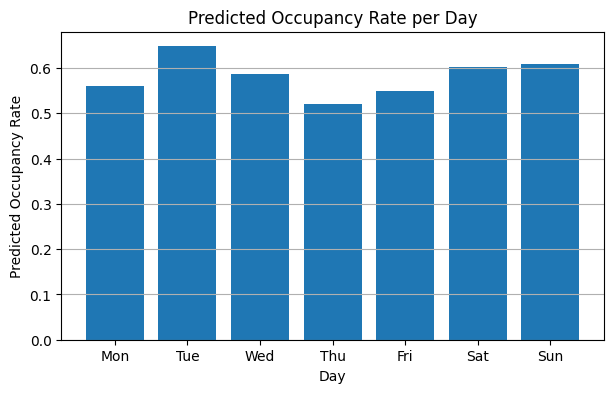

In [ ]:
day_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
occ_by_day_named = occ_by_day.rename(index=day_map)

plt.figure(figsize=(7,4))
plt.bar(occ_by_day_named.index, occ_by_day_named.values)
plt.xlabel("Day")
plt.ylabel("Predicted Occupancy Rate")
plt.title("Predicted Occupancy Rate per Day")
plt.grid(axis='y')
plt.show()